# Task 4: Forecasting Financial Inclusion in Ethiopia

## Access and Usage Forecasts for 2025–2027

This notebook produces transparent scenario-based forecasts for Ethiopia's
financial-inclusion Access and Usage indicators.

The forecasting workflow:

- validates the historical Access and Usage inputs;
- estimates recent and long-run Access growth;
- incorporates the event-impact signals developed in Task 3;
- produces conservative, baseline, and optimistic scenarios;
- estimates uncertainty using simulation;
- generates forecasts for 2025, 2026, and 2027;
- documents assumptions, risks, and limitations.

Because the available time series are sparse, the forecasts should be
interpreted as scenario projections rather than precise causal predictions.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ethiopia_fi_enriched.csv"
)

IMPACT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "event_impact_link_summary.csv"
)

ASSOCIATION_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "event_indicator_association_matrix.csv"
)

MODEL_PARAMETERS_PATH = (
    PROJECT_ROOT
    / "models"
    / "event_impact_parameters.json"
)

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

required_inputs = [
    DATA_PATH,
    IMPACT_PATH,
    ASSOCIATION_PATH,
    MODEL_PARAMETERS_PATH
]

print("TASK 4 INPUT CHECK")
print("=" * 60)

all_inputs_found = True

for file_path in required_inputs:
    exists = file_path.exists()

    print(
        f"{'PASS' if exists else 'MISSING'}: "
        f"{file_path.relative_to(PROJECT_ROOT)}"
    )

    all_inputs_found = all_inputs_found and exists

if not all_inputs_found:
    raise FileNotFoundError(
        "One or more Task 4 input files are missing."
    )

print("\nProject root:", PROJECT_ROOT)
print("Environment ready")

TASK 4 INPUT CHECK
PASS: data/processed/ethiopia_fi_enriched.csv
PASS: data/processed/event_impact_link_summary.csv
PASS: data/processed/event_indicator_association_matrix.csv
PASS: models/event_impact_parameters.json

Project root: /Users/mac/Ethiopia-FI-Interim
Environment ready


In [2]:
df = pd.read_csv(DATA_PATH)
impact_links = pd.read_csv(IMPACT_PATH)
association_matrix = pd.read_csv(
    ASSOCIATION_PATH,
    index_col=0
)

with open(
    MODEL_PARAMETERS_PATH,
    "r",
    encoding="utf-8"
) as file:
    event_model_parameters = json.load(file)

# Normalize column names.
for frame in [df, impact_links]:
    frame.columns = (
        frame.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
    )

# Convert relevant dates.
for column in [
    "observation_date",
    "event_date",
    "collection_date"
]:
    if column in df.columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

if "event_date_resolved" in impact_links.columns:
    impact_links["event_date_resolved"] = pd.to_datetime(
        impact_links["event_date_resolved"],
        errors="coerce"
    )

# Convert numeric impact fields.
for column in [
    "effect_score",
    "near_term_effect_score",
    "lag_months"
]:
    if column in impact_links.columns:
        impact_links[column] = pd.to_numeric(
            impact_links[column],
            errors="coerce"
        )

print("Enriched dataset shape:", df.shape)
print("Task 3 impact links:", len(impact_links))
print(
    "Association matrix shape:",
    association_matrix.shape
)

print("\nRecord types:")
print(df["record_type"].value_counts())

display(impact_links.head())

Enriched dataset shape: (62, 35)
Task 3 impact links: 15
Association matrix shape: (9, 10)

Record types:
record_type
observation    33
impact_link    15
event          11
target          3
Name: count, dtype: int64


,record_id,parent_id,event_name_resolved,event_date_resolved,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,confidence,direction_sign,magnitude_weight,evidence_weight,confidence_weight,effect_score,near_term_effect_score
0,IMP_0001,EVT_0001,Telebirr Launch,2021-05-17,ACCESS,ACC_OWNERSHIP,increase,high,12.0,literature,medium,1.0,3.0,0.85,0.75,1.9125,1.275000
1,IMP_0003,EVT_0001,Telebirr Launch,2021-05-17,USAGE,USG_P2P_COUNT,increase,high,6.0,empirical,medium,1.0,3.0,1.00,0.75,2.2500,1.800000
2,IMP_0002,EVT_0001,Telebirr Launch,2021-05-17,USAGE,USG_TELEBIRR_USERS,increase,high,3.0,empirical,high,1.0,3.0,1.00,1.00,3.0000,2.666667
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,ACCESS,ACC_4G_COV,increase,medium,12.0,empirical,medium,1.0,2.0,1.00,0.75,1.5000,1.000000
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12.0,literature,medium,-1.0,2.0,0.85,0.75,-1.2750,-0.850000


In [3]:
# Validated national Global Findex Access series from Task 2.
#
# The 2021 subgroup values of 56% and 36% are excluded because they
# represent male and female ownership, not the national total.

access_history = pd.DataFrame({
    "year": [
        2011,
        2014,
        2017,
        2021,
        2024
    ],
    "access_percent": [
        14.0,
        22.0,
        35.0,
        46.0,
        49.0
    ],
    "source": [
        "Global Findex 2011",
        "Global Findex 2014",
        "Global Findex 2017",
        "Global Findex 2021",
        "Global Findex 2024"
    ]
})

access_history["years_since_previous"] = (
    access_history["year"].diff()
)

access_history["change_pp"] = (
    access_history["access_percent"].diff()
)

access_history["annualized_change_pp"] = (
    access_history["change_pp"]
    / access_history["years_since_previous"]
)

print("Validated national Access history")
display(access_history)

print(
    "Latest Access value:",
    access_history.iloc[-1]["access_percent"],
    "%"
)

print(
    "Latest annualized growth:",
    round(
        access_history.iloc[-1]["annualized_change_pp"],
        2
    ),
    "percentage points per year"
)

Validated national Access history


,year,access_percent,source,years_since_previous,change_pp,annualized_change_pp
0,2011,14.0,Global Findex 2011,NaN,NaN,NaN
1,2014,22.0,Global Findex 2014,3.0,8.0,2.666667
2,2017,35.0,Global Findex 2017,3.0,13.0,4.333333
3,2021,46.0,Global Findex 2021,4.0,11.0,2.750000
4,2024,49.0,Global Findex 2024,3.0,3.0,1.000000


Latest Access value: 49.0 %
Latest annualized growth: 1.0 percentage points per year


In [4]:
usage_candidates = df[
    df["indicator_code"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("USG_ACTIVE_RATE")
].copy()

candidate_columns = [
    column
    for column in [
        "record_id",
        "indicator",
        "indicator_code",
        "value_numeric",
        "observation_date",
        "unit",
        "source_name",
        "confidence"
    ]
    if column in usage_candidates.columns
]

print("Usage baseline records found:")
display(usage_candidates[candidate_columns])

usage_values = pd.to_numeric(
    usage_candidates["value_numeric"],
    errors="coerce"
).dropna()

if usage_values.empty:
    raise ValueError(
        "No valid USG_ACTIVE_RATE value was found."
    )

usage_baseline_value = float(
    usage_values.iloc[-1]
)

usage_history = pd.DataFrame({
    "year": [2024],
    "usage_percent": [
        usage_baseline_value
    ],
    "indicator": [
        "Mobile Money Activity Rate"
    ],
    "indicator_code": [
        "USG_ACTIVE_RATE"
    ],
    "forecasting_role": [
        "Scenario-model baseline"
    ]
})

print("Validated Usage baseline")
display(usage_history)

print(
    "Usage baseline:",
    usage_baseline_value,
    "%"
)

print(
    "\nImportant limitation: only one comparable "
    "percentage-based Usage observation is available."
)

Usage baseline records found:


,record_id,indicator,indicator_code,value_numeric,observation_date,unit,source_name,confidence
24,REC_0025,Mobile Money Activity Rate,USG_ACTIVE_RATE,66.0,2024-12-31,%,Calculated,high


Validated Usage baseline


,year,usage_percent,indicator,indicator_code,forecasting_role
0,2024,66.0,Mobile Money Activity Rate,USG_ACTIVE_RATE,Scenario-model baseline


Usage baseline: 66.0 %

Important limitation: only one comparable percentage-based Usage observation is available.


In [5]:
forecast_input_summary = pd.DataFrame({
    "forecast_dimension": [
        "Access",
        "Usage"
    ],
    "baseline_year": [
        int(access_history["year"].max()),
        int(usage_history["year"].max())
    ],
    "baseline_value_percent": [
        float(
            access_history.iloc[-1][
                "access_percent"
            ]
        ),
        float(
            usage_history.iloc[-1][
                "usage_percent"
            ]
        )
    ],
    "historical_observations": [
        len(access_history),
        len(usage_history)
    ],
    "modeling_approach": [
        (
            "Blend of recent and long-run annual "
            "growth with scenario adjustments"
        ),
        (
            "Assumption-driven scenario model "
            "anchored at the 2024 activity rate"
        )
    ]
})

display(forecast_input_summary)

print(
    "Task 4 inputs are ready for model construction."
)

,forecast_dimension,baseline_year,baseline_value_percent,historical_observations,modeling_approach
0,Access,2024,49.0,5,Blend of recent and long-run annual growth wit...
1,Usage,2024,66.0,1,Assumption-driven scenario model anchored at t...


Task 4 inputs are ready for model construction.


In [6]:
# Summarize recent and future event-impact signals for forecasting.

score_column = (
    "near_term_effect_score"
    if "near_term_effect_score" in impact_links.columns
    else "effect_score"
)

impact_links[score_column] = pd.to_numeric(
    impact_links[score_column],
    errors="coerce"
).fillna(0.0)

# Use events relevant to the forecast period.
if "event_date_resolved" in impact_links.columns:
    forecast_event_links = impact_links[
        impact_links["event_date_resolved"].between(
            "2024-01-01",
            "2027-12-31"
        )
    ].copy()
else:
    forecast_event_links = impact_links.copy()

# Fall back to all relationships when no dated links are available.
if forecast_event_links.empty:
    forecast_event_links = impact_links.copy()

pillar_text = (
    forecast_event_links["pillar"]
    .fillna("")
    .astype(str)
    .str.upper()
    if "pillar" in forecast_event_links.columns
    else pd.Series(
        "",
        index=forecast_event_links.index
    )
)

indicator_text = (
    forecast_event_links["related_indicator"]
    .fillna("")
    .astype(str)
    .str.upper()
    if "related_indicator" in forecast_event_links.columns
    else pd.Series(
        "",
        index=forecast_event_links.index
    )
)

access_mask = (
    pillar_text.str.contains("ACCESS", na=False)
    | indicator_text.str.startswith("ACC_")
)

usage_mask = (
    pillar_text.str.contains("USAGE", na=False)
    | indicator_text.str.startswith("USG_")
)

access_event_signal_raw = float(
    forecast_event_links.loc[
        access_mask,
        score_column
    ].sum()
)

usage_event_signal_raw = float(
    forecast_event_links.loc[
        usage_mask,
        score_column
    ].sum()
)

# Convert unrestricted raw scores into bounded values from -1 to +1.
access_event_signal = float(
    np.tanh(access_event_signal_raw / 6.0)
)

usage_event_signal = float(
    np.tanh(usage_event_signal_raw / 6.0)
)

event_signal_summary = pd.DataFrame({
    "dimension": [
        "Access",
        "Usage"
    ],
    "raw_event_signal": [
        access_event_signal_raw,
        usage_event_signal_raw
    ],
    "standardized_event_signal": [
        access_event_signal,
        usage_event_signal
    ],
    "relationships_used": [
        int(access_mask.sum()),
        int(usage_mask.sum())
    ]
})

display(event_signal_summary.round(3))

print(
    "Standardized signals range from -1 to +1."
)

,dimension,raw_event_signal,standardized_event_signal,relationships_used
0,Access,0.638,0.106,1
1,Usage,3.287,0.499,3


Standardized signals range from -1 to +1.


In [7]:
# Access historical growth assumptions.

access_growth_observations = (
    access_history["annualized_change_pp"]
    .dropna()
)

recent_access_growth = float(
    access_growth_observations.iloc[-1]
)

long_run_access_growth = float(
    (
        access_history["access_percent"].iloc[-1]
        - access_history["access_percent"].iloc[0]
    )
    / (
        access_history["year"].iloc[-1]
        - access_history["year"].iloc[0]
    )
)

# Give more weight to the recent slowdown.
access_trend_anchor = (
    0.70 * recent_access_growth
    + 0.30 * long_run_access_growth
)

# Keep the event adjustment intentionally small.
access_event_adjustment = (
    0.35 * access_event_signal
)

usage_event_adjustment = (
    0.50 * usage_event_signal
)

access_growth_rates = {
    "Conservative": max(
        0.25,
        access_trend_anchor * 0.65 - 0.10
    ),
    "Baseline": max(
        0.50,
        access_trend_anchor
        + access_event_adjustment
    ),
    "Optimistic": min(
        4.00,
        access_trend_anchor * 1.35
        + max(
            access_event_adjustment,
            0.20
        )
    )
}

# Usage has only one comparable historical percentage observation,
# so these assumptions are deliberately scenario-driven.
usage_growth_rates = {
    "Conservative": max(
        0.00,
        0.50
        + min(
            usage_event_adjustment,
            0.00
        )
    ),
    "Baseline": max(
        0.25,
        1.50
        + usage_event_adjustment
    ),
    "Optimistic": min(
        5.00,
        2.75
        + max(
            usage_event_adjustment,
            0.25
        )
    )
}

# Annual uncertainty in percentage points.
access_growth_sd = {
    "Conservative": 0.60,
    "Baseline": 0.80,
    "Optimistic": 1.10
}

usage_growth_sd = {
    "Conservative": 0.90,
    "Baseline": 1.20,
    "Optimistic": 1.60
}

scenario_assumptions = pd.DataFrame([
    {
        "dimension": "Access",
        "scenario": scenario,
        "annual_growth_pp": rate,
        "annual_uncertainty_sd": access_growth_sd[scenario]
    }
    for scenario, rate in access_growth_rates.items()
] + [
    {
        "dimension": "Usage",
        "scenario": scenario,
        "annual_growth_pp": rate,
        "annual_uncertainty_sd": usage_growth_sd[scenario]
    }
    for scenario, rate in usage_growth_rates.items()
])

print(
    "Recent Access growth:",
    round(recent_access_growth, 2),
    "pp per year"
)

print(
    "Long-run Access growth:",
    round(long_run_access_growth, 2),
    "pp per year"
)

print(
    "Blended Access trend:",
    round(access_trend_anchor, 2),
    "pp per year"
)

display(
    scenario_assumptions.round(2)
)

Recent Access growth: 1.0 pp per year
Long-run Access growth: 2.69 pp per year
Blended Access trend: 1.51 pp per year


,dimension,scenario,annual_growth_pp,annual_uncertainty_sd
0,Access,Conservative,0.88,0.6
1,Access,Baseline,1.54,0.8
2,Access,Optimistic,2.24,1.1
3,Usage,Conservative,0.50,0.9
4,Usage,Baseline,1.75,1.2
5,Usage,Optimistic,3.00,1.6


In [8]:
forecast_years = np.array([
    2025,
    2026,
    2027
])

scenario_order = [
    "Conservative",
    "Baseline",
    "Optimistic"
]


def simulate_forecasts(
    dimension,
    baseline_value,
    scenario_rates,
    scenario_sd,
    years,
    simulations=10000,
    seed=42
):
    """
    Produce cumulative additive forecasts in percentage points.

    Each simulation draws a separate annual growth rate and
    accumulates it from the 2024 baseline.
    """

    rng = np.random.default_rng(seed)

    forecast_rows = []

    for scenario in scenario_order:
        mean_growth = float(
            scenario_rates[scenario]
        )

        growth_sd = float(
            scenario_sd[scenario]
        )

        annual_growth_draws = rng.normal(
            loc=mean_growth,
            scale=growth_sd,
            size=(
                simulations,
                len(years)
            )
        )

        simulated_values = (
            baseline_value
            + np.cumsum(
                annual_growth_draws,
                axis=1
            )
        )

        simulated_values = np.clip(
            simulated_values,
            0,
            100
        )

        for year_index, year in enumerate(years):
            year_values = simulated_values[
                :,
                year_index
            ]

            forecast_rows.append({
                "dimension": dimension,
                "scenario": scenario,
                "year": int(year),
                "forecast_percent": float(
                    np.median(year_values)
                ),
                "lower_90_percent": float(
                    np.percentile(
                        year_values,
                        5
                    )
                ),
                "upper_90_percent": float(
                    np.percentile(
                        year_values,
                        95
                    )
                ),
                "annual_growth_assumption_pp": (
                    mean_growth
                ),
                "annual_growth_uncertainty_sd": (
                    growth_sd
                ),
                "simulations": simulations
            })

    return pd.DataFrame(
        forecast_rows
    )


access_forecasts = simulate_forecasts(
    dimension="Access",
    baseline_value=49.0,
    scenario_rates=access_growth_rates,
    scenario_sd=access_growth_sd,
    years=forecast_years,
    simulations=10000,
    seed=42
)

usage_forecasts = simulate_forecasts(
    dimension="Usage",
    baseline_value=66.0,
    scenario_rates=usage_growth_rates,
    scenario_sd=usage_growth_sd,
    years=forecast_years,
    simulations=10000,
    seed=84
)

forecast_results = pd.concat(
    [
        access_forecasts,
        usage_forecasts
    ],
    ignore_index=True
)

forecast_results["scenario"] = pd.Categorical(
    forecast_results["scenario"],
    categories=scenario_order,
    ordered=True
)

forecast_results = (
    forecast_results
    .sort_values(
        [
            "dimension",
            "scenario",
            "year"
        ]
    )
    .reset_index(drop=True)
)

display(
    forecast_results.round(2)
)

,dimension,scenario,year,forecast_percent,lower_90_percent,upper_90_percent,annual_growth_assumption_pp,annual_growth_uncertainty_sd,simulations
0,Access,Conservative,2025,49.88,48.90,50.89,0.88,0.6,10000
1,Access,Conservative,2026,50.78,49.37,52.20,0.88,0.6,10000
2,Access,Conservative,2027,51.65,49.92,53.40,0.88,0.6,10000
3,Access,Baseline,2025,50.54,49.20,51.86,1.54,0.8,10000
4,Access,Baseline,2026,52.06,50.21,53.93,1.54,0.8,10000
5,Access,Baseline,2027,53.61,51.33,55.85,1.54,0.8,10000
6,Access,Optimistic,2025,51.22,49.36,53.03,2.24,1.1,10000
7,Access,Optimistic,2026,53.48,50.90,56.04,2.24,1.1,10000
8,Access,Optimistic,2027,55.71,52.58,58.82,2.24,1.1,10000
9,Usage,Conservative,2025,66.49,65.03,67.97,0.50,0.9,10000


In [9]:
forecast_display = forecast_results.copy()

forecast_display["forecast_with_90_interval"] = (
    forecast_display["forecast_percent"]
    .round(1)
    .astype(str)
    + "% ("
    + forecast_display["lower_90_percent"]
    .round(1)
    .astype(str)
    + "%–"
    + forecast_display["upper_90_percent"]
    .round(1)
    .astype(str)
    + "%)"
)

forecast_summary_table = forecast_display.pivot(
    index=[
        "dimension",
        "scenario"
    ],
    columns="year",
    values="forecast_with_90_interval"
)

display(forecast_summary_table)

year                                   2025                 2026                 2027
dimension scenario                                                                   
Access    Conservative  49.9% (48.9%–50.9%)  50.8% (49.4%–52.2%)  51.6% (49.9%–53.4%)
          Baseline      50.5% (49.2%–51.9%)  52.1% (50.2%–53.9%)  53.6% (51.3%–55.9%)
          Optimistic    51.2% (49.4%–53.0%)  53.5% (50.9%–56.0%)  55.7% (52.6%–58.8%)
Usage     Conservative  66.5% (65.0%–68.0%)  67.0% (64.9%–69.1%)  67.5% (65.0%–70.1%)
          Baseline      67.8% (65.8%–69.7%)  69.5% (66.7%–72.3%)  71.3% (67.9%–74.6%)
          Optimistic    69.0% (66.4%–71.6%)  72.0% (68.3%–75.7%)  75.0% (70.5%–79.6%)

In [10]:
forecast_output_path = (
    OUTPUT_DIR
    / "forecasts_2025_2027.csv"
)

scenario_output_path = (
    OUTPUT_DIR
    / "forecast_scenario_assumptions.csv"
)

forecast_results.to_csv(
    forecast_output_path,
    index=False
)

scenario_assumptions.to_csv(
    scenario_output_path,
    index=False
)

print("Saved:", forecast_output_path)
print("Saved:", scenario_output_path)
print("Forecast rows:", len(forecast_results))

Saved: /Users/mac/Ethiopia-FI-Interim/data/processed/forecasts_2025_2027.csv
Saved: /Users/mac/Ethiopia-FI-Interim/data/processed/forecast_scenario_assumptions.csv
Forecast rows: 18


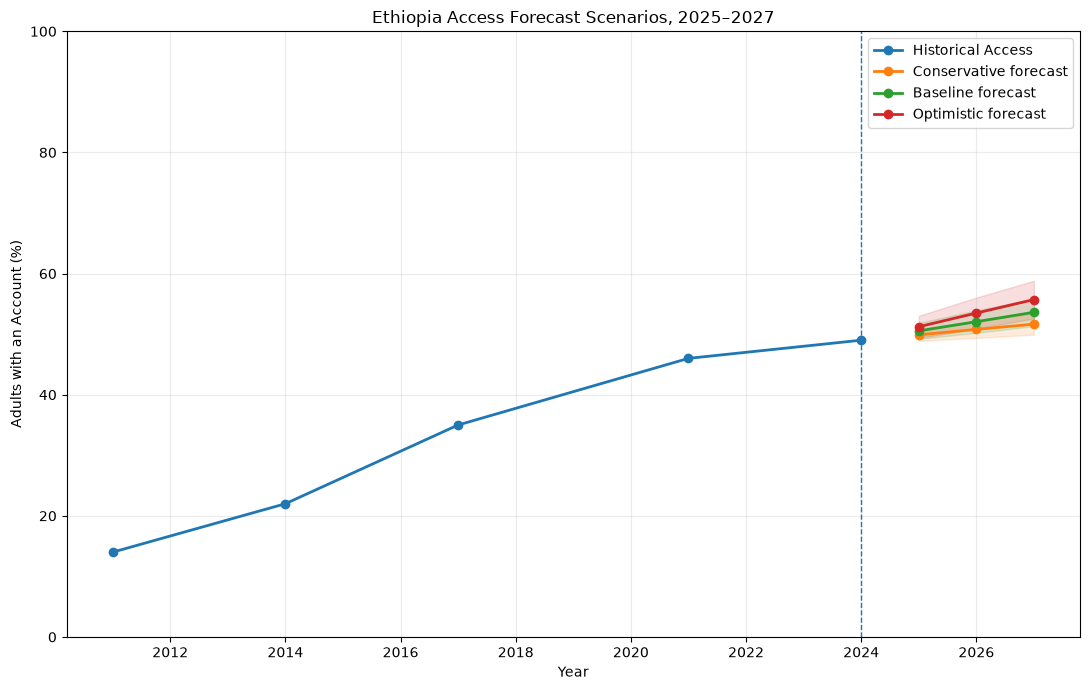

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/access_forecast_scenarios.png


In [11]:
fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.plot(
    access_history["year"],
    access_history["access_percent"],
    marker="o",
    linewidth=2,
    label="Historical Access"
)

for scenario in scenario_order:
    scenario_data = forecast_results[
        (
            forecast_results["dimension"]
            == "Access"
        )
        & (
            forecast_results["scenario"]
            == scenario
        )
    ].sort_values("year")

    line, = ax.plot(
        scenario_data["year"],
        scenario_data["forecast_percent"],
        marker="o",
        linewidth=2,
        label=f"{scenario} forecast"
    )

    ax.fill_between(
        scenario_data["year"],
        scenario_data["lower_90_percent"],
        scenario_data["upper_90_percent"],
        alpha=0.15,
        color=line.get_color()
    )

ax.axvline(
    2024,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Ethiopia Access Forecast Scenarios, 2025–2027"
)

ax.set_xlabel("Year")
ax.set_ylabel("Adults with an Account (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

access_figure_path = (
    FIGURE_DIR
    / "access_forecast_scenarios.png"
)

fig.savefig(
    access_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", access_figure_path)

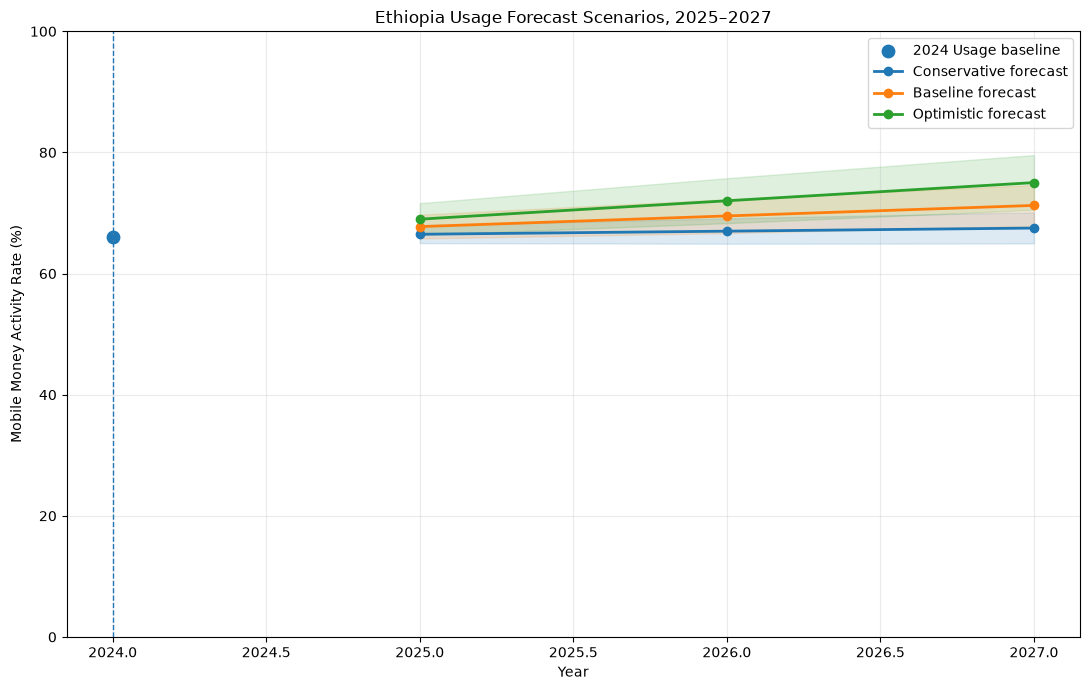

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/usage_forecast_scenarios.png


In [12]:
fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.scatter(
    [2024],
    [usage_baseline_value],
    s=80,
    label="2024 Usage baseline"
)

for scenario in scenario_order:
    scenario_data = forecast_results[
        (
            forecast_results["dimension"]
            == "Usage"
        )
        & (
            forecast_results["scenario"]
            == scenario
        )
    ].sort_values("year")

    line, = ax.plot(
        scenario_data["year"],
        scenario_data["forecast_percent"],
        marker="o",
        linewidth=2,
        label=f"{scenario} forecast"
    )

    ax.fill_between(
        scenario_data["year"],
        scenario_data["lower_90_percent"],
        scenario_data["upper_90_percent"],
        alpha=0.15,
        color=line.get_color()
    )

ax.axvline(
    2024,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Ethiopia Usage Forecast Scenarios, 2025–2027"
)

ax.set_xlabel("Year")
ax.set_ylabel("Mobile Money Activity Rate (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

usage_figure_path = (
    FIGURE_DIR
    / "usage_forecast_scenarios.png"
)

fig.savefig(
    usage_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", usage_figure_path)

In [13]:
forecast_parameters = {
    "model_name": (
        "Scenario-based Access and Usage forecast model"
    ),
    "forecast_period": [
        2025,
        2026,
        2027
    ],
    "access": {
        "baseline_year": 2024,
        "baseline_percent": 49.0,
        "historical_observations": 5,
        "recent_growth_pp_per_year": (
            recent_access_growth
        ),
        "long_run_growth_pp_per_year": (
            long_run_access_growth
        ),
        "blended_trend_pp_per_year": (
            access_trend_anchor
        ),
        "event_signal": (
            access_event_signal
        ),
        "scenario_growth_rates": (
            access_growth_rates
        ),
        "scenario_uncertainty_sd": (
            access_growth_sd
        )
    },
    "usage": {
        "baseline_year": 2024,
        "baseline_percent": (
            usage_baseline_value
        ),
        "historical_observations": 1,
        "event_signal": (
            usage_event_signal
        ),
        "scenario_growth_rates": (
            usage_growth_rates
        ),
        "scenario_uncertainty_sd": (
            usage_growth_sd
        )
    },
    "simulation": {
        "simulations_per_scenario": 10000,
        "interval": "90 percent",
        "lower_percentile": 5,
        "upper_percentile": 95,
        "forecast_bounds": [
            0,
            100
        ]
    },
    "limitations": [
        (
            "Access contains only five national "
            "survey observations."
        ),
        (
            "Usage contains only one comparable "
            "percentage-based observation."
        ),
        (
            "Usage projections are scenario assumptions, "
            "not fitted time-series forecasts."
        ),
        (
            "Event-impact scores are relative association "
            "signals rather than causal estimates."
        ),
        (
            "Forecast intervals represent model uncertainty "
            "and do not capture every structural risk."
        )
    ]
}

forecast_parameters_path = (
    MODEL_DIR
    / "forecast_parameters.json"
)

with open(
    forecast_parameters_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        forecast_parameters,
        file,
        indent=2
    )

print("Saved:", forecast_parameters_path)

Saved: /Users/mac/Ethiopia-FI-Interim/models/forecast_parameters.json


## Task 4 Forecasting Findings

### Forecasting approach

The forecasting model produces conservative, baseline, and optimistic
projections for Ethiopia's Access and Usage indicators from 2025 through
2027.

Access forecasts are based on:

- five validated national account-ownership observations;
- the recent annual growth rate;
- the long-run annual growth rate;
- a weighted trend that gives greater importance to the recent slowdown;
- bounded event-impact adjustments from Task 3.

Usage forecasts are anchored at the 2024 Mobile Money Activity Rate of
66%. Because only one directly comparable percentage-based Usage
observation is available, Usage projections are scenario-driven rather
than fitted time-series forecasts.

### Access forecast interpretation

Account ownership reached 49% in 2024. Under the baseline scenario, Access
is projected to rise gradually through 2027.

The conservative scenario represents slower progress caused by
affordability constraints, weak active usage, implementation delays, and
limited conversion of registrations into unique account owners.

The optimistic scenario assumes stronger effects from digital identity,
competition, interoperability, infrastructure improvements, and improved
customer activation.

### Usage forecast interpretation

Usage begins from the 2024 Mobile Money Activity Rate of 66%.

The baseline scenario assumes gradual improvement in activity as mobile
money infrastructure, merchant networks, payment interoperability, and
consumer adoption expand.

The optimistic scenario assumes faster activation of registered users,
greater merchant acceptance, stronger person-to-person transaction growth,
and improved reliability.

The conservative scenario assumes that registered-account growth continues
to exceed active usage because of inactive accounts, duplicate accounts,
affordability constraints, and limited everyday use cases.

### Uncertainty

Each scenario was simulated 10,000 times using annual growth uncertainty.
The reported ranges are 90% simulation intervals.

The intervals widen over time because annual uncertainty accumulates from
2025 through 2027.

These intervals represent uncertainty within the selected scenario
assumptions. They do not include every possible economic, regulatory,
political, technological, or measurement shock.

### Main assumptions

- Forecast values remain between 0% and 100%.
- Annual percentage-point growth is additive.
- Recent Access growth receives greater weight than earlier rapid growth.
- Task 3 event signals provide small adjustments rather than dominating the
  historical trend.
- Conservative, baseline, and optimistic scenarios remain ordered.
- The 2024 Usage value is treated as the forecasting baseline.
- Usage projections are scenario assumptions because the historical series
  is insufficient for a fitted statistical trend.

### Main limitations

- Access contains only five national survey observations.
- Usage contains only one comparable percentage-based observation.
- Survey measures and administrative registered-user counts are not directly
  interchangeable.
- Event-impact scores are relative associations rather than causal estimates.
- Structural breaks and unexpected policy changes are not explicitly modeled.
- Forecast intervals depend on the selected growth-rate distributions.
- Forecast results should be interpreted as planning scenarios rather than
  exact predictions.

### Task 4 conclusion

The projections indicate continued improvement in both Access and Usage
through 2027, although the pace depends strongly on customer activation,
affordability, infrastructure quality, merchant adoption, interoperability,
and the conversion of registered accounts into regular use.

The scenario framework is transparent and reproducible. It is suitable for
the dashboard and final report, while clearly communicating the substantial
uncertainty caused by sparse historical data.

In [14]:
# Summarize the final forecast year for reporting.

forecast_2027 = (
    forecast_results[
        forecast_results["year"].eq(2027)
    ]
    .copy()
    .sort_values(
        ["dimension", "scenario"]
    )
    .reset_index(drop=True)
)

forecast_2027["forecast_summary"] = (
    forecast_2027["forecast_percent"]
    .round(1)
    .astype(str)
    + "% (90% interval: "
    + forecast_2027["lower_90_percent"]
    .round(1)
    .astype(str)
    + "%–"
    + forecast_2027["upper_90_percent"]
    .round(1)
    .astype(str)
    + "%)"
)

display(
    forecast_2027[
        [
            "dimension",
            "scenario",
            "forecast_summary"
        ]
    ]
)

baseline_2027 = forecast_2027[
    forecast_2027["scenario"].eq("Baseline")
]

print("\nBASELINE 2027 FORECASTS")
print("=" * 50)

for _, row in baseline_2027.iterrows():
    print(
        f'{row["dimension"]}: '
        f'{row["forecast_summary"]}'
    )

,dimension,scenario,forecast_summary
0,Access,Conservative,51.6% (90% interval: 49.9%–53.4%)
1,Access,Baseline,53.6% (90% interval: 51.3%–55.9%)
2,Access,Optimistic,55.7% (90% interval: 52.6%–58.8%)
3,Usage,Conservative,67.5% (90% interval: 65.0%–70.1%)
4,Usage,Baseline,71.3% (90% interval: 67.9%–74.6%)
5,Usage,Optimistic,75.0% (90% interval: 70.5%–79.6%)



BASELINE 2027 FORECASTS
Access: 53.6% (90% interval: 51.3%–55.9%)
Usage: 71.3% (90% interval: 67.9%–74.6%)


In [15]:
# Validate forecast structure and logical consistency.

validation_results = []

expected_rows = 18

validation_results.append({
    "check": "Expected number of forecast rows",
    "passed": len(forecast_results) == expected_rows,
    "detail": f"{len(forecast_results)} of {expected_rows}"
})

validation_results.append({
    "check": "All forecasts remain between 0 and 100",
    "passed": forecast_results["forecast_percent"]
        .between(0, 100)
        .all(),
    "detail": "Percentage bounds"
})

validation_results.append({
    "check": "Lower intervals do not exceed forecasts",
    "passed": (
        forecast_results["lower_90_percent"]
        <= forecast_results["forecast_percent"]
    ).all(),
    "detail": "Lower ≤ forecast"
})

validation_results.append({
    "check": "Upper intervals are not below forecasts",
    "passed": (
        forecast_results["upper_90_percent"]
        >= forecast_results["forecast_percent"]
    ).all(),
    "detail": "Forecast ≤ upper"
})

scenario_rank = {
    "Conservative": 0,
    "Baseline": 1,
    "Optimistic": 2
}

ordering_check = True

for dimension in ["Access", "Usage"]:
    for year in forecast_years:
        subset = forecast_results[
            forecast_results["dimension"].eq(dimension)
            & forecast_results["year"].eq(year)
        ].copy()

        subset["scenario_rank"] = (
            subset["scenario"]
            .astype(str)
            .map(scenario_rank)
        )

        values = (
            subset
            .sort_values("scenario_rank")[
                "forecast_percent"
            ]
            .to_numpy()
        )

        if not np.all(np.diff(values) >= 0):
            ordering_check = False

validation_results.append({
    "check": "Scenario ordering is logical",
    "passed": ordering_check,
    "detail": "Conservative ≤ Baseline ≤ Optimistic"
})

forecast_validation = pd.DataFrame(
    validation_results
)

display(forecast_validation)

if not forecast_validation["passed"].all():
    raise AssertionError(
        "One or more forecast validation checks failed."
    )

print("All forecast sanity checks passed.")

,check,passed,detail
0,Expected number of forecast rows,True,18 of 18
1,All forecasts remain between 0 and 100,True,Percentage bounds
2,Lower intervals do not exceed forecasts,True,Lower ≤ forecast
3,Upper intervals are not below forecasts,True,Forecast ≤ upper
4,Scenario ordering is logical,True,Conservative ≤ Baseline ≤ Optimistic


All forecast sanity checks passed.


In [16]:
required_task_4_files = [
    OUTPUT_DIR / "forecasts_2025_2027.csv",
    OUTPUT_DIR / "forecast_scenario_assumptions.csv",
    MODEL_DIR / "forecast_parameters.json",
    FIGURE_DIR / "access_forecast_scenarios.png",
    FIGURE_DIR / "usage_forecast_scenarios.png"
]

print("TASK 4 OUTPUT CHECK")
print("=" * 65)

all_outputs_found = True

for file_path in required_task_4_files:
    exists = file_path.exists()

    print(
        f"{'PASS' if exists else 'MISSING'}: "
        f"{file_path.relative_to(PROJECT_ROOT)}"
    )

    all_outputs_found = (
        all_outputs_found and exists
    )

print(
    "\nFINAL RESULT:",
    "PASS"
    if all_outputs_found
    else "CHECK MISSING FILES"
)

TASK 4 OUTPUT CHECK
PASS: data/processed/forecasts_2025_2027.csv
PASS: data/processed/forecast_scenario_assumptions.csv
PASS: models/forecast_parameters.json
PASS: reports/figures/access_forecast_scenarios.png
PASS: reports/figures/usage_forecast_scenarios.png

FINAL RESULT: PASS
